In [1]:
import os
import time
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

from resnet_torch import ResNet18

In [2]:
%load_ext autoreload   

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on device: {device}")

Running on device: cuda


In [6]:
baseline_model = ResNet18()

state_dict = torch.load('resnet18_cifar10.pth', map_location=torch.device('cpu'))
baseline_model.load_state_dict(state_dict)
baseline_model.to(device)
print()

In [15]:
def test(model, data_loader):
    model.eval()
    correct = 0
    total = 0
    model.to(device)

    start_time = time.time()
    
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    end_time = time.time()
    accuracy = 100 * correct / total
    inference_time = end_time - start_time
    
    print(f'Accuracy: {accuracy:.2f}%')
    print(f'Inference Time: {inference_time:.2f} seconds')
    return accuracy, inference_time

In [9]:
# dataloading
stats = ((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(*stats),
])

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=100, shuffle=False, num_workers=2)

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_test)
# We only need a small subset for calibration (e.g., 1000 images)
train_subset, _ = torch.utils.data.random_split(trainset, [1000, 49000])
calib_loader = torch.utils.data.DataLoader(train_subset, batch_size=32, shuffle=False, num_workers=2)

100%|██████████| 170M/170M [00:04<00:00, 37.0MB/s] 


In [16]:
baseline_acc, baseline_time = test(baseline_model, testloader)

Accuracy: 95.30%
Inference Time: 1.21 seconds


In [7]:
conv_count = 0
linear_count = 0

print(f"{'Layer Name':<30} {'Type':<10} {'Parameters':<15}")
print("-" * 60)

for name, module in baseline_model.named_modules():
    if isinstance(module, nn.Conv2d):
        conv_count += 1
        # Weights only (bias=False in ResNet usually)
        params = module.weight.numel()
        print(f"{name:<30} {'Conv2d':<10} {params:<15}")
        
    elif isinstance(module, nn.Linear):
        linear_count += 1
        # Weights + Bias (if applicable)
        params = module.weight.numel()
        if module.bias is not None:
            params += module.bias.numel()
        print(f"{name:<30} {'Linear':<10} {params:<15}")

print("-" * 60)
print(f"Total Conv2d Layers: {conv_count}")
print(f"Total Linear Layers: {linear_count}")

Layer Name                     Type       Parameters     
------------------------------------------------------------
conv1                          Conv2d     1728           
layer1.0.conv1                 Conv2d     36864          
layer1.0.conv2                 Conv2d     36864          
layer1.1.conv1                 Conv2d     36864          
layer1.1.conv2                 Conv2d     36864          
layer2.0.conv1                 Conv2d     73728          
layer2.0.conv2                 Conv2d     147456         
layer2.0.shortcut.0            Conv2d     8192           
layer2.1.conv1                 Conv2d     147456         
layer2.1.conv2                 Conv2d     147456         
layer3.0.conv1                 Conv2d     294912         
layer3.0.conv2                 Conv2d     589824         
layer3.0.shortcut.0            Conv2d     32768          
layer3.1.conv1                 Conv2d     589824         
layer3.1.conv2                 Conv2d     589824         
layer4.0.co

In [19]:
layer_names = []
accuracies = []

# iterate over all relevant layers
for name, module in baseline_model.named_modules():
    if isinstance(module, (nn.Conv2d, nn.Linear)):
        temp_model = copy.deepcopy(baseline_model)
        
        module_to_prune = dict(temp_model.named_modules())[name]
        prune.l1_unstructured(module_to_prune, name='weight', amount=0.9)
        
        acc, _ = test(temp_model, testloader)
        print(f"Pruned {name}: {acc:.2f}%")
        
        layer_names.append(name)
        accuracies.append(acc)

Accuracy: 85.38%
Inference Time: 1.24 seconds
Pruned conv1: 85.38%
Accuracy: 95.27%
Inference Time: 1.25 seconds
Pruned layer1.0.conv1: 95.27%
Accuracy: 95.14%
Inference Time: 1.24 seconds
Pruned layer1.0.conv2: 95.14%
Accuracy: 95.30%
Inference Time: 1.23 seconds
Pruned layer1.1.conv1: 95.30%
Accuracy: 95.19%
Inference Time: 1.30 seconds
Pruned layer1.1.conv2: 95.19%
Accuracy: 92.77%
Inference Time: 1.32 seconds
Pruned layer2.0.conv1: 92.77%
Accuracy: 93.86%
Inference Time: 1.24 seconds
Pruned layer2.0.conv2: 93.86%
Accuracy: 95.02%
Inference Time: 1.30 seconds
Pruned layer2.0.shortcut.0: 95.02%
Accuracy: 94.88%
Inference Time: 1.26 seconds
Pruned layer2.1.conv1: 94.88%
Accuracy: 94.73%
Inference Time: 1.27 seconds
Pruned layer2.1.conv2: 94.73%
Accuracy: 86.99%
Inference Time: 1.28 seconds
Pruned layer3.0.conv1: 86.99%
Accuracy: 92.39%
Inference Time: 1.20 seconds
Pruned layer3.0.conv2: 92.39%
Accuracy: 95.23%
Inference Time: 1.25 seconds
Pruned layer3.0.shortcut.0: 95.23%
Accuracy: 8

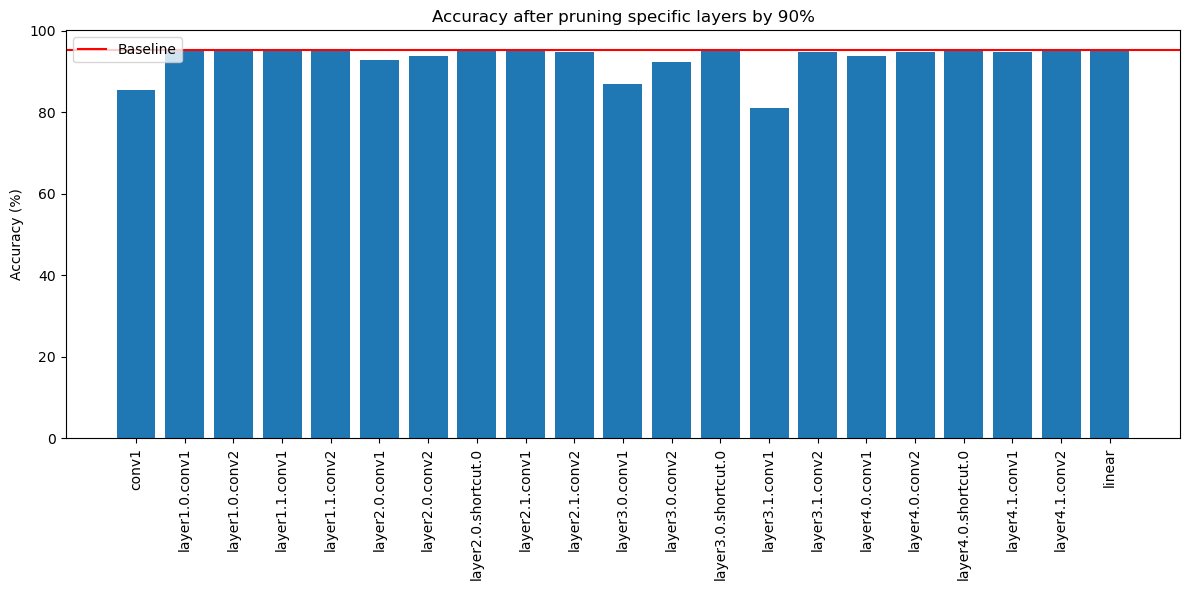

In [20]:
plt.figure(figsize=(12, 6))
plt.bar(layer_names, accuracies)
plt.axhline(y=baseline_acc, color='r', linestyle='-', label='Baseline')
plt.xticks(rotation=90)
plt.ylabel('Accuracy (%)')
plt.title('Accuracy after pruning specific layers by 90%')
plt.legend()
plt.tight_layout()
plt.savefig('layer_sensitivity.png')
plt.show()

In [21]:
target_acc = baseline_acc - 2.0
print(f"Target Accuracy Threshold: {target_acc:.2f}%")

# binary search
low = 0
high = 99
best_k = 0

# cache results to avoid re-running same k
history = {}

while low <= high:
    mid = (low + high) // 2
    
    if mid in history:
        acc = history[mid]
    else:
        temp_model = copy.deepcopy(baseline_model)

        # prune by k%
        for module in temp_model.modules():
            if isinstance(module, nn.Linear):
                prune.l1_unstructured(module, name='weight', amount=mid/100.0)
       
        result = test(temp_model, testloader)
        acc = result[0] if isinstance(result, tuple) else result
        
        history[mid] = acc
        print(f"Testing k={mid}% -> Accuracy: {acc:.2f}%")
    
    if acc >= target_acc:
        best_k = mid # this k works, go higher
        low = mid + 1
    else:
        high = mid - 1 # this k failed, must go lower

print(f"\nMaximum integer k: {best_k}%")
print(f"Accuracy at k={best_k}%: {history[best_k]:.2f}%")

Target Accuracy Threshold: 93.30%
Accuracy: 95.29%
Inference Time: 1.18 seconds
Testing k=49% -> Accuracy: 95.29%
Accuracy: 95.23%
Inference Time: 1.16 seconds
Testing k=74% -> Accuracy: 95.23%
Accuracy: 95.24%
Inference Time: 1.16 seconds
Testing k=87% -> Accuracy: 95.24%
Accuracy: 95.19%
Inference Time: 1.12 seconds
Testing k=93% -> Accuracy: 95.19%
Accuracy: 95.07%
Inference Time: 1.14 seconds
Testing k=96% -> Accuracy: 95.07%
Accuracy: 92.35%
Inference Time: 1.19 seconds
Testing k=98% -> Accuracy: 92.35%
Accuracy: 94.48%
Inference Time: 1.28 seconds
Testing k=97% -> Accuracy: 94.48%

Maximum integer k: 97%
Accuracy at k=97%: 94.48%
